# Multichannel Blind Deblurring (Stationary)

This notebook demonstrates multichannel blind deblurring using `blurtool` as the convolution backend, comparing two convolution modes: **FFT** (circular convolution via `torch.fft`) and **spatial** (`F.conv2d` with circular padding).

**Setup**: a single image $I$ is blurred with two unknown kernels $F_1$ and $F_2$, producing two observations $X_1 = I * F_1$ and $X_2 = I * F_2$.

**Key identity**: by commutativity of convolution,
$$X_1 * k_2 - X_2 * k_1 = 0 \iff (k_1,\, k_2) \propto (F_1,\, F_2).$$

Blind deblurring finds the stacked kernel vector $v = (k_1, k_2)$ on the unit sphere that minimises
$$J(k_1, k_2) = \|X_1 * k_2 - X_2 * k_1\|^2,$$
using Riemannian gradient descent with a golden-section line search.
All convolutions are performed by `blurtool.StationaryBlur.forward()`; gradients w.r.t. the kernels are obtained via PyTorch autograd.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import blurtool

## Image and kernels

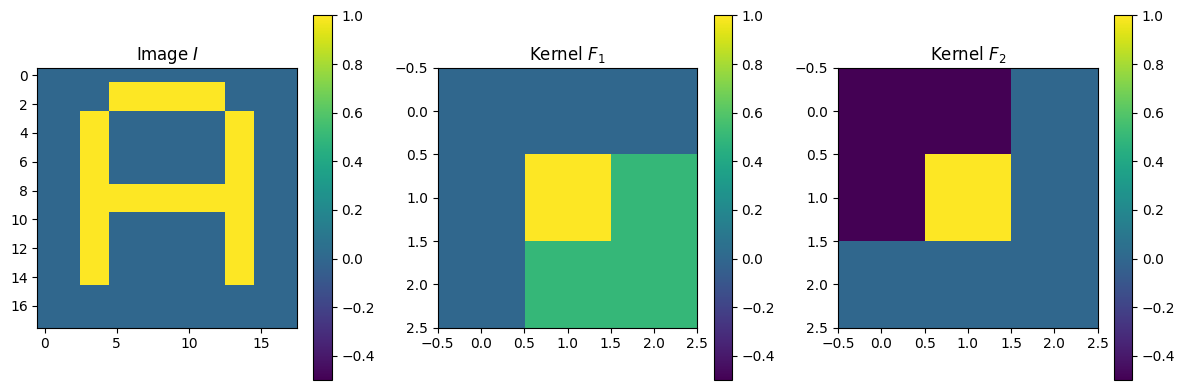

In [2]:
# 18x18 image: stylised letter A (1-pixel margin on every side)
I_np = np.zeros((18, 18), dtype=np.float64)
I_np[1:3,  5:13] = 1   # top bar
I_np[3:15, 3:5]  = 1   # left side
I_np[3:15, 13:15]= 1   # right side
I_np[8:10, 5:13] = 1   # middle bar

I = torch.tensor(I_np)

# Two 3x3 blur kernels
F1_data = torch.tensor([[0.0,  0.0, 0.0],
                         [0.0,  1.0, 0.5],
                         [0.0,  0.5, 0.5]], dtype=torch.float64)

F2_data = torch.tensor([[-0.5, -0.5, 0.0],
                         [-0.5,  1.0, 0.0],
                         [ 0.0,  0.0, 0.0]], dtype=torch.float64)

kshape = (3, 3)
vmin = min(I_np.min(), F1_data.numpy().min(), F2_data.numpy().min())
vmax = max(I_np.max(), F1_data.numpy().max(), F2_data.numpy().max())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, data, title in [(axes[0], I_np,             'Image $I$'),
                         (axes[1], F1_data.numpy(),  'Kernel $F_1$'),
                         (axes[2], F2_data.numpy(),  'Kernel $F_2$')]:
    im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Shared optimisation machinery

`deblur` is mode-agnostic: it takes a cost function `J_fn(vF)` and a gradient function `grad_fn(vF)`, defined separately for each convolution mode below.

In [3]:
def deblur(vF0, nIter, J_fn, grad_fn):
    """
    Riemannian gradient descent on the unit sphere with a golden-section line search.
    Minimises J_fn(vF)  s.t.  ||vF|| = 1.
    """
    phi = 2.0 - (1.0 + np.sqrt(5.0)) / 2.0  # golden-section parameter ~0.382
    vF = vF0.clone().double()

    for i in range(nIter):
        G = grad_fn(vF)
        L = G - torch.dot(vF, G) * vF   # Riemannian gradient
        L = L / torch.norm(L)

        tha = torch.tensor(-np.pi / 180.0, dtype=torch.float64)
        thb = torch.tensor(0.0, dtype=torch.float64)

        for _ in range(50):             # golden-section line search
            thc = tha + phi * (thb - tha)
            thd = thb + phi * (tha - thb)
            if J_fn(torch.cos(thc) * vF + torch.sin(thc) * L) > \
               J_fn(torch.cos(thd) * vF + torch.sin(thd) * L):
                tha = thc.clone()
            else:
                thb = thd.clone()

        vF = torch.cos(thb) * vF + torch.sin(thb) * L

        if (i + 1) % 100 == 0:
            print(f'iter {i+1:4d}:  J = {J_fn(vF).item():.4e}')

    return vF


def extract_kernels(vF_est):
    """Split vF into two blurtool.Kernel objects with max-abs normalisation."""
    n = kshape[0] * kshape[1]
    k1_data = vF_est[:n].reshape(kshape).detach()
    k2_data = vF_est[n:].reshape(kshape).detach()
    k1_data = k1_data / k1_data.abs().max()
    k2_data = k2_data / k2_data.abs().max()
    return blurtool.Kernel(kshape, psf_data=k1_data), blurtool.Kernel(kshape, psf_data=k2_data)


def plot_results(k1_est, k2_est, suptitle=''):
    fig, axes = plt.subplots(3, 2, figsize=(8, 10))
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    rows = [
        (F1_data.numpy(),                             F2_data.numpy(),                             'True $F_1$',  'True $F_2$'),
        (k1_est().numpy(),                            k2_est().numpy(),                            'Est. $F_1$',  'Est. $F_2$'),
        (k1_est().numpy() - F1_data.numpy(),          k2_est().numpy() - F2_data.numpy(),          'Error $F_1$', 'Error $F_2$'),
    ]
    for row_idx, (dl, dr, tl, tr) in enumerate(rows):
        for col_idx, (data, title) in enumerate([(dl, tl), (dr, tr)]):
            ax = axes[row_idx, col_idx]
            im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
            ax.set_title(title)
            plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


# Shared initial guess: delta at the centre of each kernel
vF0 = torch.zeros(2 * kshape[0] * kshape[1], dtype=torch.float64)
centre = kshape[0] * kshape[1] // 2
vF0[centre]                         = 1.0
vF0[kshape[0] * kshape[1] + centre] = 1.0
vF0 = vF0 / torch.norm(vF0)

nIter = 2000

## Mode-specific J and gradient functions

`make_blind_deblur_fns(X1, X2, mode)` returns `(J_fn, grad_fn)` for either mode.
The residual $X_1 * k_2 - X_2 * k_1$ and its gradient are computed entirely through `blurtool.StationaryBlur.forward()`.

In [4]:
def make_blind_deblur_fns(X1, X2, mode):
    """
    Build cost and gradient functions for the blind deblurring problem.

    Parameters
    ----------
    X1, X2 : torch.Tensor  —  blurred observations
    mode   : str           —  'fft' or 'spatial'

    Returns
    -------
    J_fn   : vF -> scalar cost
    grad_fn: vF -> Euclidean gradient
    """
    def _residual(k1_data, k2_data):
        b1 = blurtool.StationaryBlur(blurtool.Kernel(kshape, psf_data=k1_data), mode=mode)
        b2 = blurtool.StationaryBlur(blurtool.Kernel(kshape, psf_data=k2_data), mode=mode)
        return b2.forward(X1) - b1.forward(X2)

    def J_fn(vF):
        n = kshape[0] * kshape[1]
        A = _residual(vF[:n].reshape(kshape), vF[n:].reshape(kshape))
        return (A * A).sum()

    def grad_fn(vF):
        n = kshape[0] * kshape[1]
        k1 = vF[:n].reshape(kshape).detach().clone().requires_grad_(True)
        k2 = vF[n:].reshape(kshape).detach().clone().requires_grad_(True)
        A = _residual(k1, k2)
        (A * A).sum().backward()
        return torch.cat([k1.grad.flatten(), k2.grad.flatten()]).detach()

    return J_fn, grad_fn

---
## FFT path  (`mode='fft'`)

`blurtool.StationaryBlur` with `mode='fft'` pads the kernel to image size with `F.pad`, shifts its centre to the origin with `torch.roll`, and multiplies in the frequency domain — exact circular convolution. Both `F.pad` and `torch.roll` are differentiable, so autograd flows through the FFT path.

J at true kernels (FFT): 9.380939225414928e-30


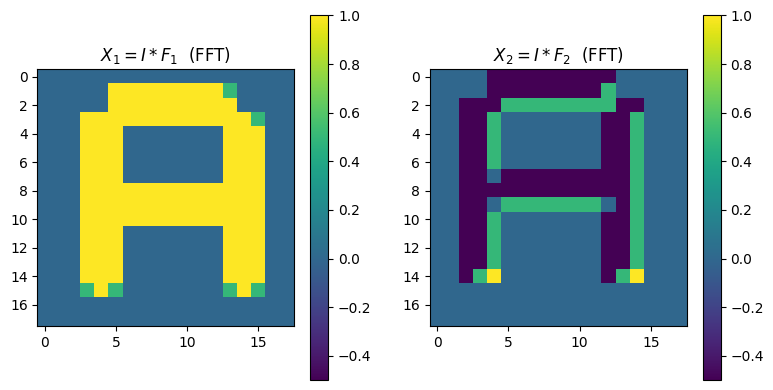

In [5]:
with torch.no_grad():
    X1_fft = blurtool.StationaryBlur(blurtool.Kernel(kshape, psf_data=F1_data), mode='fft').forward(I)
    X2_fft = blurtool.StationaryBlur(blurtool.Kernel(kshape, psf_data=F2_data), mode='fft').forward(I)

vF_true = torch.cat([F1_data.flatten(), F2_data.flatten()])
J_fft, grad_fft = make_blind_deblur_fns(X1_fft, X2_fft, mode='fft')
print('J at true kernels (FFT):', J_fft(vF_true / vF_true.norm()).item())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, data, title in [(axes[0], X1_fft.numpy(), '$X_1 = I * F_1$  (FFT)'),
                         (axes[1], X2_fft.numpy(), '$X_2 = I * F_2$  (FFT)')]:
    im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [6]:
print('=== FFT path ===')
vF_est_fft = deblur(vF0, nIter, J_fft, grad_fft)

=== FFT path ===
iter  100:  J = 6.4584e-01
iter  200:  J = 2.1418e-01
iter  300:  J = 1.1175e-01
iter  400:  J = 7.6324e-02
iter  500:  J = 5.8146e-02
iter  600:  J = 4.6128e-02
iter  700:  J = 3.7298e-02
iter  800:  J = 3.0535e-02
iter  900:  J = 2.5243e-02
iter 1000:  J = 2.1039e-02
iter 1100:  J = 1.7655e-02
iter 1200:  J = 1.4899e-02
iter 1300:  J = 1.2631e-02
iter 1400:  J = 1.0748e-02
iter 1500:  J = 9.1734e-03
iter 1600:  J = 7.8479e-03
iter 1700:  J = 6.7264e-03
iter 1800:  J = 5.7736e-03
iter 1900:  J = 4.9614e-03
iter 2000:  J = 4.2672e-03


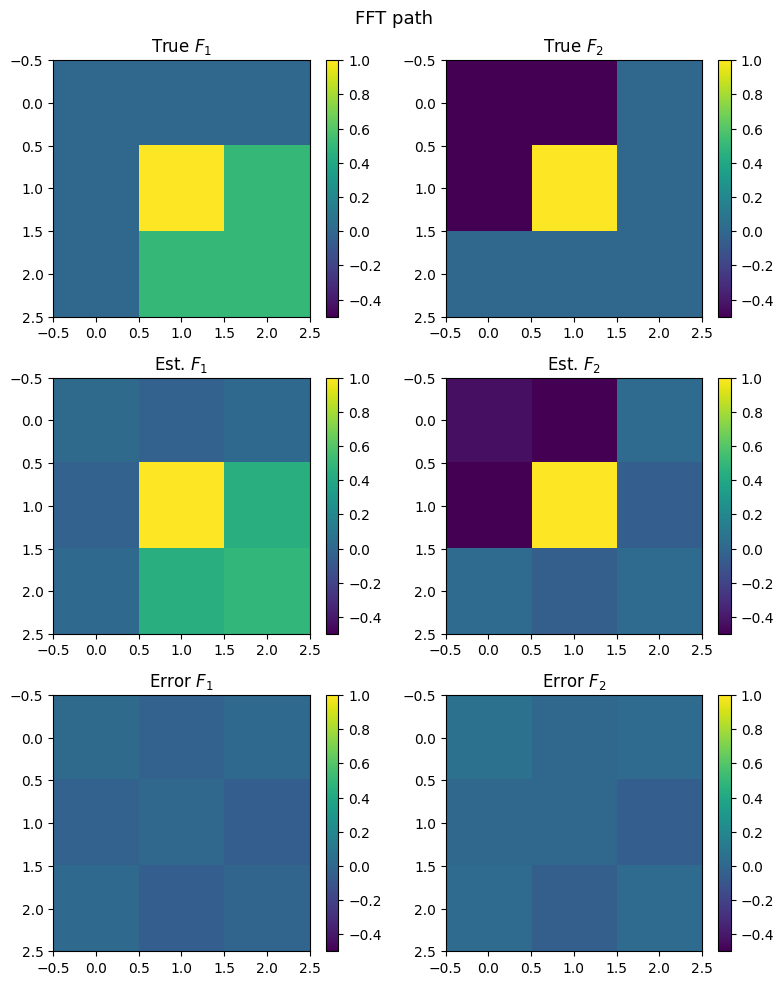

In [7]:
k1_est_fft, k2_est_fft = extract_kernels(vF_est_fft)
plot_results(k1_est_fft, k2_est_fft, suptitle='FFT path')

---
## Spatial path  (`mode='spatial'`)

`blurtool.StationaryBlur` with `mode='spatial'` uses `F.conv2d` with **circular padding** pre-applied to the input. This is equivalent to the FFT path (circular convolution), and autograd also flows through it directly.

Max diff FFT vs spatial (X1): 6.454261757392051e-16
J at true kernels (spatial): 4.930380657631324e-31


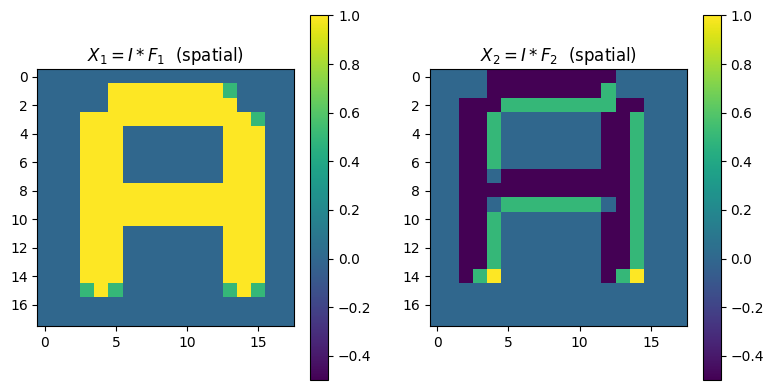

In [8]:
with torch.no_grad():
    X1_spa = blurtool.StationaryBlur(blurtool.Kernel(kshape, psf_data=F1_data), mode='spatial').forward(I)
    X2_spa = blurtool.StationaryBlur(blurtool.Kernel(kshape, psf_data=F2_data), mode='spatial').forward(I)

print('Max diff FFT vs spatial (X1):', (X1_fft - X1_spa).abs().max().item())

J_spa, grad_spa = make_blind_deblur_fns(X1_spa, X2_spa, mode='spatial')
print('J at true kernels (spatial):', J_spa(vF_true / vF_true.norm()).item())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, data, title in [(axes[0], X1_spa.numpy(), '$X_1 = I * F_1$  (spatial)'),
                         (axes[1], X2_spa.numpy(), '$X_2 = I * F_2$  (spatial)')]:
    im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [9]:
print('=== Spatial path ===')
vF_est_spa = deblur(vF0, nIter, J_spa, grad_spa)

=== Spatial path ===
iter  100:  J = 6.4584e-01
iter  200:  J = 2.1418e-01
iter  300:  J = 1.1175e-01
iter  400:  J = 7.6325e-02
iter  500:  J = 5.8147e-02
iter  600:  J = 4.6128e-02
iter  700:  J = 3.7298e-02
iter  800:  J = 3.0535e-02
iter  900:  J = 2.5243e-02
iter 1000:  J = 2.1039e-02
iter 1100:  J = 1.7655e-02
iter 1200:  J = 1.4899e-02
iter 1300:  J = 1.2631e-02
iter 1400:  J = 1.0748e-02
iter 1500:  J = 9.1733e-03
iter 1600:  J = 7.8477e-03
iter 1700:  J = 6.7262e-03
iter 1800:  J = 5.7734e-03
iter 1900:  J = 4.9612e-03
iter 2000:  J = 4.2670e-03


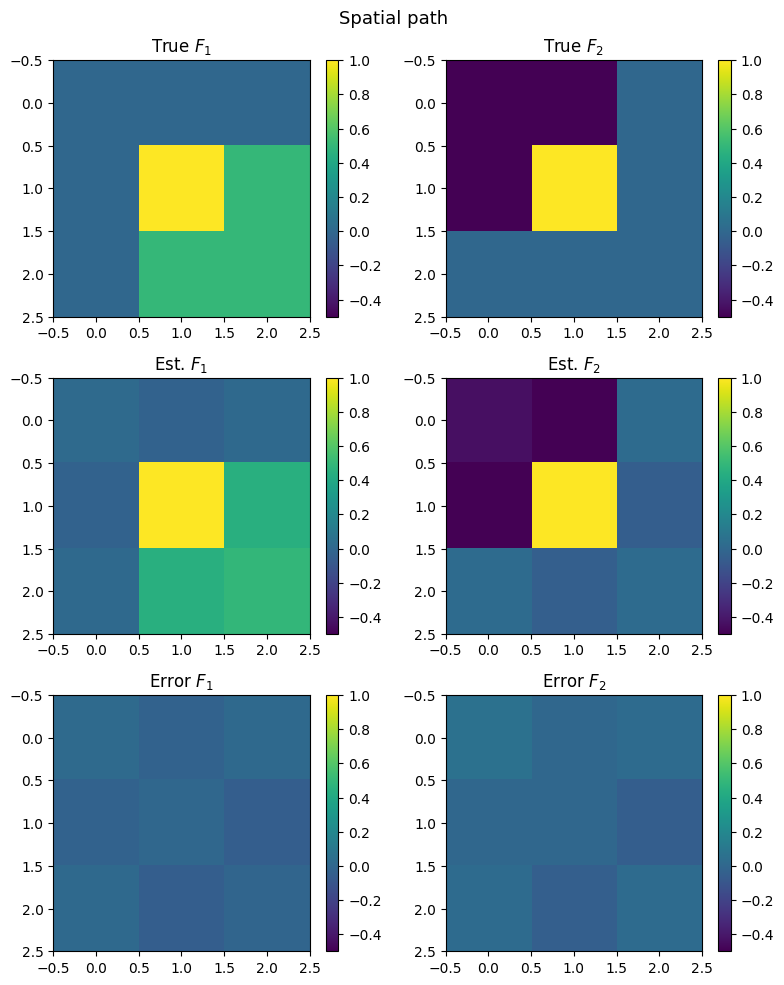

In [10]:
k1_est_spa, k2_est_spa = extract_kernels(vF_est_spa)
plot_results(k1_est_spa, k2_est_spa, suptitle='Spatial path')

---
## Comparison

Both paths solve the same problem, so their estimates should be nearly identical.

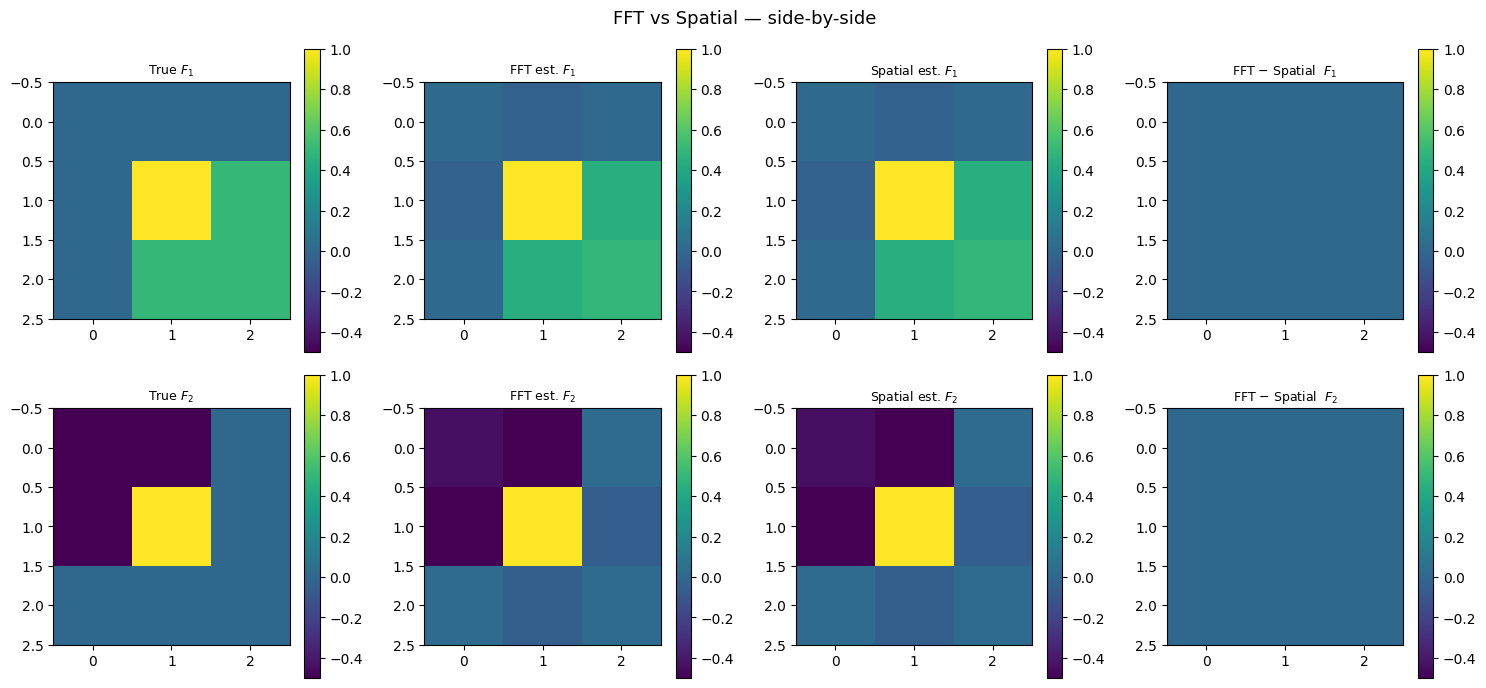

Max diff FFT vs spatial — F1: 0.0000,  F2: 0.0000


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.suptitle('FFT vs Spatial — side-by-side', fontsize=13)

rows = [
    (F1_data, 'True $F_1$', k1_est_fft, k2_est_fft, '$F_1$'),
    (F2_data, 'True $F_2$', k1_est_spa, k2_est_spa, '$F_2$'),
]

for row_idx, (true_k, true_title, est_fft_k, est_spa_k, label) in enumerate([
    (F1_data, 'True $F_1$', k1_est_fft, k1_est_spa, '$F_1$'),
    (F2_data, 'True $F_2$', k2_est_fft, k2_est_spa, '$F_2$'),
]):
    diff = est_fft_k().detach().numpy() - est_spa_k().detach().numpy()
    panels = [
        (true_k.numpy(),               true_title),
        (est_fft_k().detach().numpy(), f'FFT est. {label}'),
        (est_spa_k().detach().numpy(), f'Spatial est. {label}'),
        (diff,                          f'FFT $-$ Spatial  {label}'),
    ]
    for col_idx, (data, title) in enumerate(panels):
        ax = axes[row_idx, col_idx]
        im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print(f'Max diff FFT vs spatial — '
      f'F1: {(k1_est_fft() - k1_est_spa()).abs().max().item():.4f},  '
      f'F2: {(k2_est_fft() - k2_est_spa()).abs().max().item():.4f}')